In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(repr)
library(readxl)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

In [3]:
# Data Location and files
data_folder_dir <- "./../data/scRNAseq/"
files <- list.files(path = data_folder_dir, pattern = "^GSM")
files

[1] "GSM6506105_counts_Y2.txt"   "GSM6506106_counts_Y3.txt"  
[3] "GSM6506107_counts_Y5.txt"   "GSM6506108_counts_MJ10.txt"
[5] "GSM6506109_counts_MJ11.txt"

In [4]:
# Readd Metadata
metadata <- read_excel(paste0(data_folder_dir, "OV_scRNAseq_celltypeLabel.xlsx"))
metadata <- metadata[, 1:3]
colnames(metadata) <- c('Cell_ID', 'Sample', 'Fine_grain_annotations')
print(dim(metadata))
print(table(metadata$Fine_grain_annotations))
head(metadata, 3)

New names:
• `` -> `...4`


[1] 16682     3

       B/Plasma cells     Endothelial cells Fibro1 (EIF4A3, STAR) 
                   28                  1639                  8293 
   Fibro2 (RBP1, DCN)   Fibro3 (RAMP1, CFD)         Fibro4 (CCL2) 
                 1640                   186                   241 
 Fibro5 (FN1, COL3A1)           Macrophages     Mesothelial cells 
                  459                   314                   249 
       Myofibroblasts               T cells          Tumour cells 
                 2235                   787                   611 


Cell_ID,Sample,Fine_grain_annotations
<chr>,<chr>,<chr>
AAACGGGCAAGCTGGA_1,MJ10,Fibro4 (CCL2)
AAACGGGCAGTTCATG_1,MJ10,Endothelial cells
AAAGTAGAGTTAGCGG_1,MJ10,Macrophages


In [5]:
# Read count data of different patient and filter the data based on barcode given in supplimentary file
sampleIndex = c(3, 4, 5, 1, 2)
seuratOb_lst <- list()
i = 1
for (f in files){
    scRNAseq_raw <- data.table::fread(paste0(data_folder_dir, f), index = "V1")
    scRNAseq_raw <- as.data.frame(scRNAseq_raw)
    rownames(scRNAseq_raw) <- scRNAseq_raw$V1
    scRNAseq_raw$V1 <- NULL
    seuratObj <- CreateSeuratObject(counts = scRNAseq_raw, names.field = sampleIndex[i], 
                                    project = "HGSOV")
    print(seuratObj)

    sampleID <- str_extract(f, "(Y\\d+|MJ\\d+)")
    # Select the data that passed quality control
    patient_metadata <- filter(metadata, Sample == sampleID)
    
    qc_barcode <- patient_metadata$Cell_ID
    print(length(qc_barcode))
    seuratObj <- subset(seuratObj, cells = qc_barcode)
    print(seuratObj)
    
    # Add the metadata - cell type annotation
    seuratObj$patient <- patient_metadata$Sample
    seuratObj$cell_type_annotation <- patient_metadata$Fine_grain_annotations
    
    # Append the seurat object to list
    seuratOb_lst <- append(seuratOb_lst, seuratObj)
    i = i+ 1
}

Warning message in data.table::fread(paste0(data_folder_dir, f), index = "V1"):
“Detected 328 column names but the data has 329 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“Input parameters result in NA values for initial cell identities. Setting all initial idents to the project name”


An object of class Seurat 
19915 features across 328 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts
[1] 328
An object of class Seurat 
19915 features across 328 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts


Warning message in data.table::fread(paste0(data_folder_dir, f), index = "V1"):
“Detected 6384 column names but the data has 6385 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“Input parameters result in NA values for initial cell identities. Setting all initial idents to the project name”


An object of class Seurat 
19915 features across 6384 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts
[1] 6384
An object of class Seurat 
19915 features across 6384 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts


Warning message in data.table::fread(paste0(data_folder_dir, f), index = "V1"):
“Detected 7588 column names but the data has 7589 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“Input parameters result in NA values for initial cell identities. Setting all initial idents to the project name”


An object of class Seurat 
19915 features across 7588 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts
[1] 7588
An object of class Seurat 
19915 features across 7588 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts


Warning message in data.table::fread(paste0(data_folder_dir, f), index = "V1"):
“Detected 426 column names but the data has 427 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


An object of class Seurat 
19915 features across 426 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts
[1] 426
An object of class Seurat 
19915 features across 426 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts


Warning message in data.table::fread(paste0(data_folder_dir, f), index = "V1"):
“Detected 1956 column names but the data has 1957 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


An object of class Seurat 
19915 features across 1956 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts
[1] 1956
An object of class Seurat 
19915 features across 1956 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 1 layer present: counts


In [6]:
# merge all seurat object into one seurat object
merged_Ob<- merge(seuratOb_lst[[1]], y = seuratOb_lst[c(2:length(seuratOb_lst))],
                                   merge.data = TRUE,
                                   project = "HGSOV" )
print(merged_Ob)
print(table(merged_Ob$patient))
print(table(merged_Ob$cell_type_annotation))
head(merged_Ob@meta.data, 5)

An object of class Seurat 
19915 features across 16682 samples within 1 assay 
Active assay: RNA (19915 features, 0 variable features)
 5 layers present: counts.1, counts.2, counts.3, counts.4, counts.5

MJ10 MJ11   Y2   Y3   Y5 
 426 1956  328 6384 7588 

       B/Plasma cells     Endothelial cells Fibro1 (EIF4A3, STAR) 
                   28                  1639                  8293 
   Fibro2 (RBP1, DCN)   Fibro3 (RAMP1, CFD)         Fibro4 (CCL2) 
                 1640                   186                   241 
 Fibro5 (FN1, COL3A1)           Macrophages     Mesothelial cells 
                  459                   314                   249 
       Myofibroblasts               T cells          Tumour cells 
                 2235                   787                   611 


,orig.ident,nCount_RNA,nFeature_RNA,patient,cell_type_annotation
,<chr>,<dbl>,<int>,<chr>,<chr>
AAACGGGTCACTCTTA_3,HGSOV,7995,1858,Y2,"Fibro1 (EIF4A3, STAR)"
AAAGCAAGTGCAACTT_3,HGSOV,3263,1376,Y2,"Fibro5 (FN1, COL3A1)"
AAAGTAGCAGGTTTCA_3,HGSOV,1073,525,Y2,Myofibroblasts
AACACGTTCCATTCTA_3,HGSOV,7778,2397,Y2,"Fibro1 (EIF4A3, STAR)"
AACCATGAGGGCACTA_3,HGSOV,1624,808,Y2,"Fibro1 (EIF4A3, STAR)"


In [7]:
print(table(merged_Ob$patient, merged_Ob$cell_type_annotation))

      
       B/Plasma cells Endothelial cells Fibro1 (EIF4A3, STAR)
  MJ10              1                93                    34
  MJ11              5               386                   213
  Y2                0                52                    58
  Y3                2               239                  3843
  Y5               20               869                  4145
      
       Fibro2 (RBP1, DCN) Fibro3 (RAMP1, CFD) Fibro4 (CCL2)
  MJ10                 11                   0             2
  MJ11                126                  16            18
  Y2                   19                   0             2
  Y3                 1009                  39           123
  Y5                  475                 131            96
      
       Fibro5 (FN1, COL3A1) Macrophages Mesothelial cells Myofibroblasts
  MJ10                   21          32                28            103
  MJ11                   77          47                49            107
  Y2                     16 

In [8]:
# normalization, feature selection, and scaling
merged_Ob <- merged_Ob %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(nfeatures = 3000,verbose = FALSE) %>%
  ScaleData(verbose = FALSE) 

print(merged_Ob)

An object of class Seurat 
19915 features across 16682 samples within 1 assay 
Active assay: RNA (19915 features, 3000 variable features)
 11 layers present: counts.1, counts.2, counts.3, counts.4, counts.5, data.1, data.2, data.3, data.4, data.5, scale.data


In [9]:
# PCA, umap and tSNE
merged_Ob <- RunPCA(merged_Ob, npcs = 50, verbose = FALSE)
merged_Ob <- RunTSNE(merged_Ob, reduction = "pca", dims = 1:30, verbose = FALSE)
merged_Ob <- RunUMAP(merged_Ob, reduction = "pca", dims = 1:30, verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


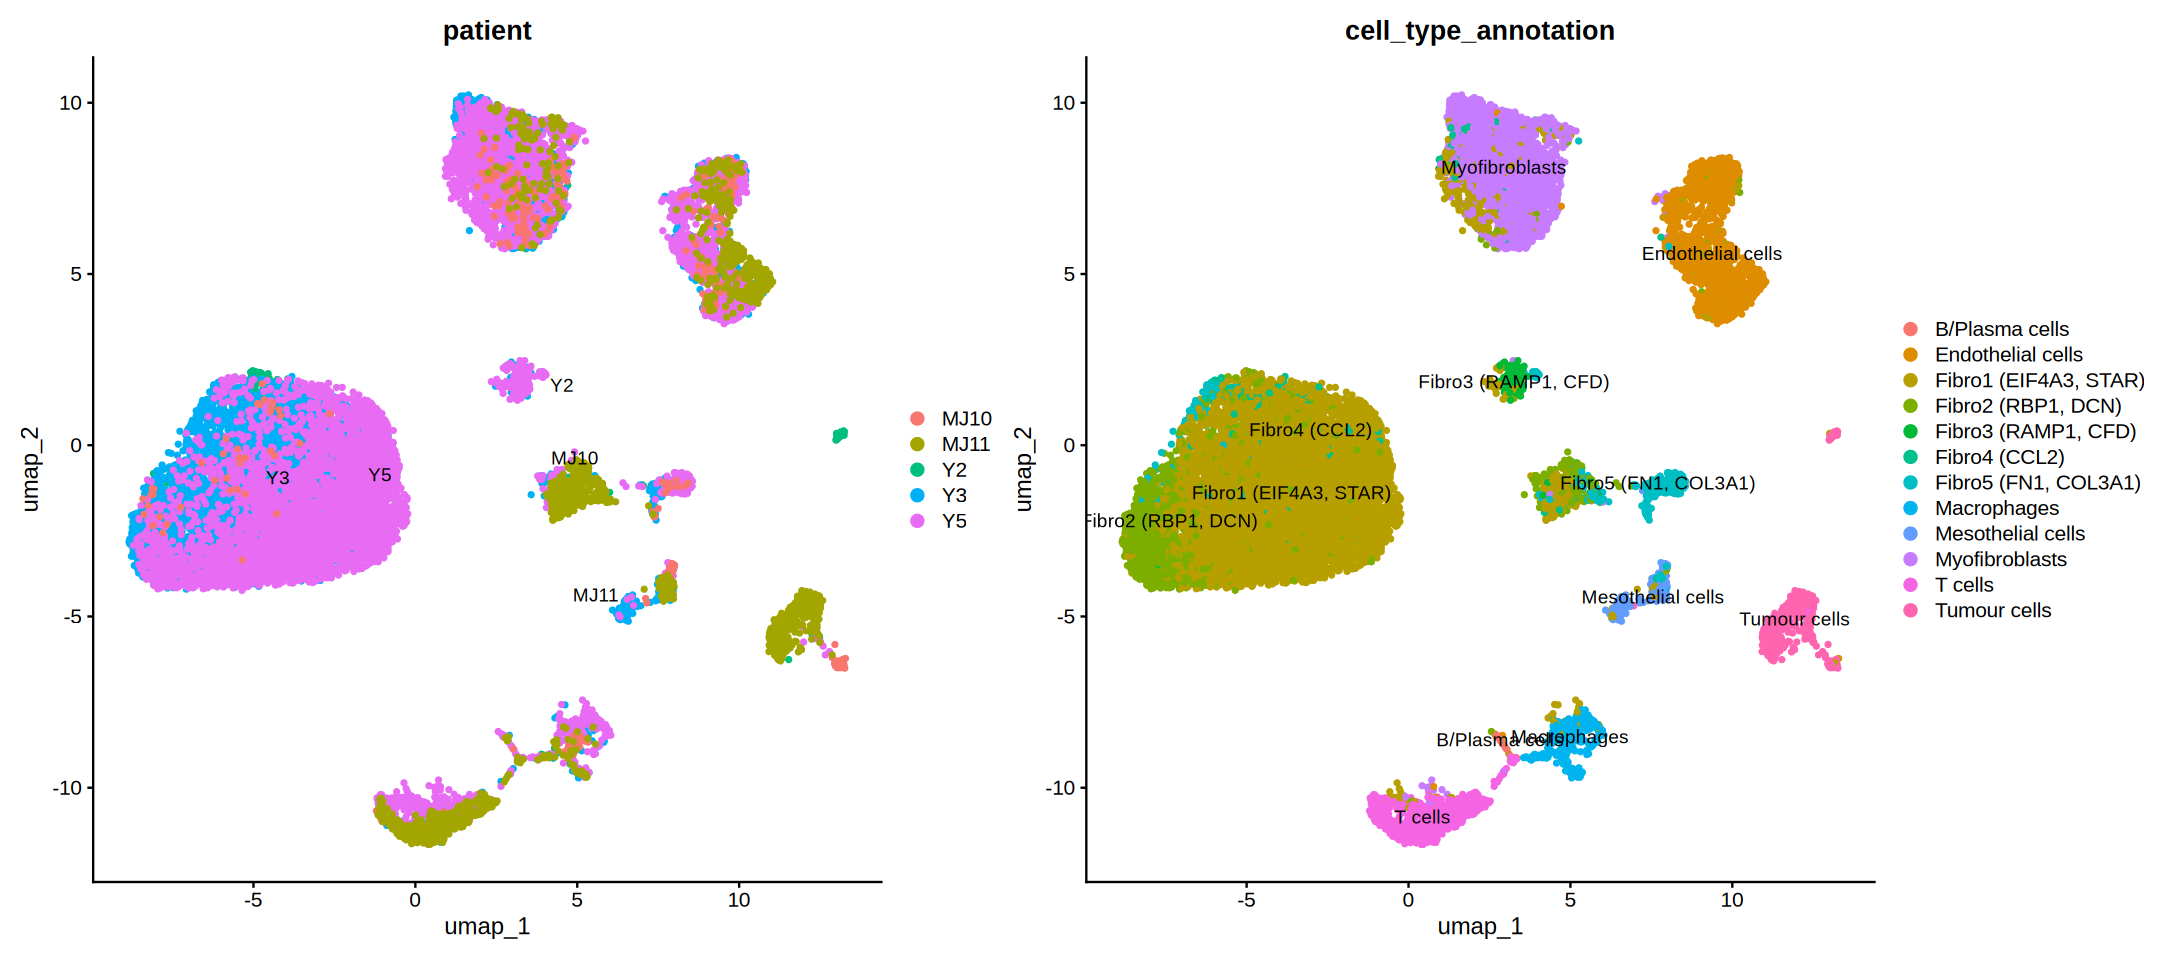

In [10]:
options(repr.plot.height = 8, repr.plot.width = 18)
p1 <- DimPlot(merged_Ob, reduction = "umap", label = TRUE, group.by = "patient", pt.size = 1)
p2 <- DimPlot(merged_Ob, reduction = "umap", label = TRUE, group.by = "cell_type_annotation", pt.size = 1)
p1 + p2

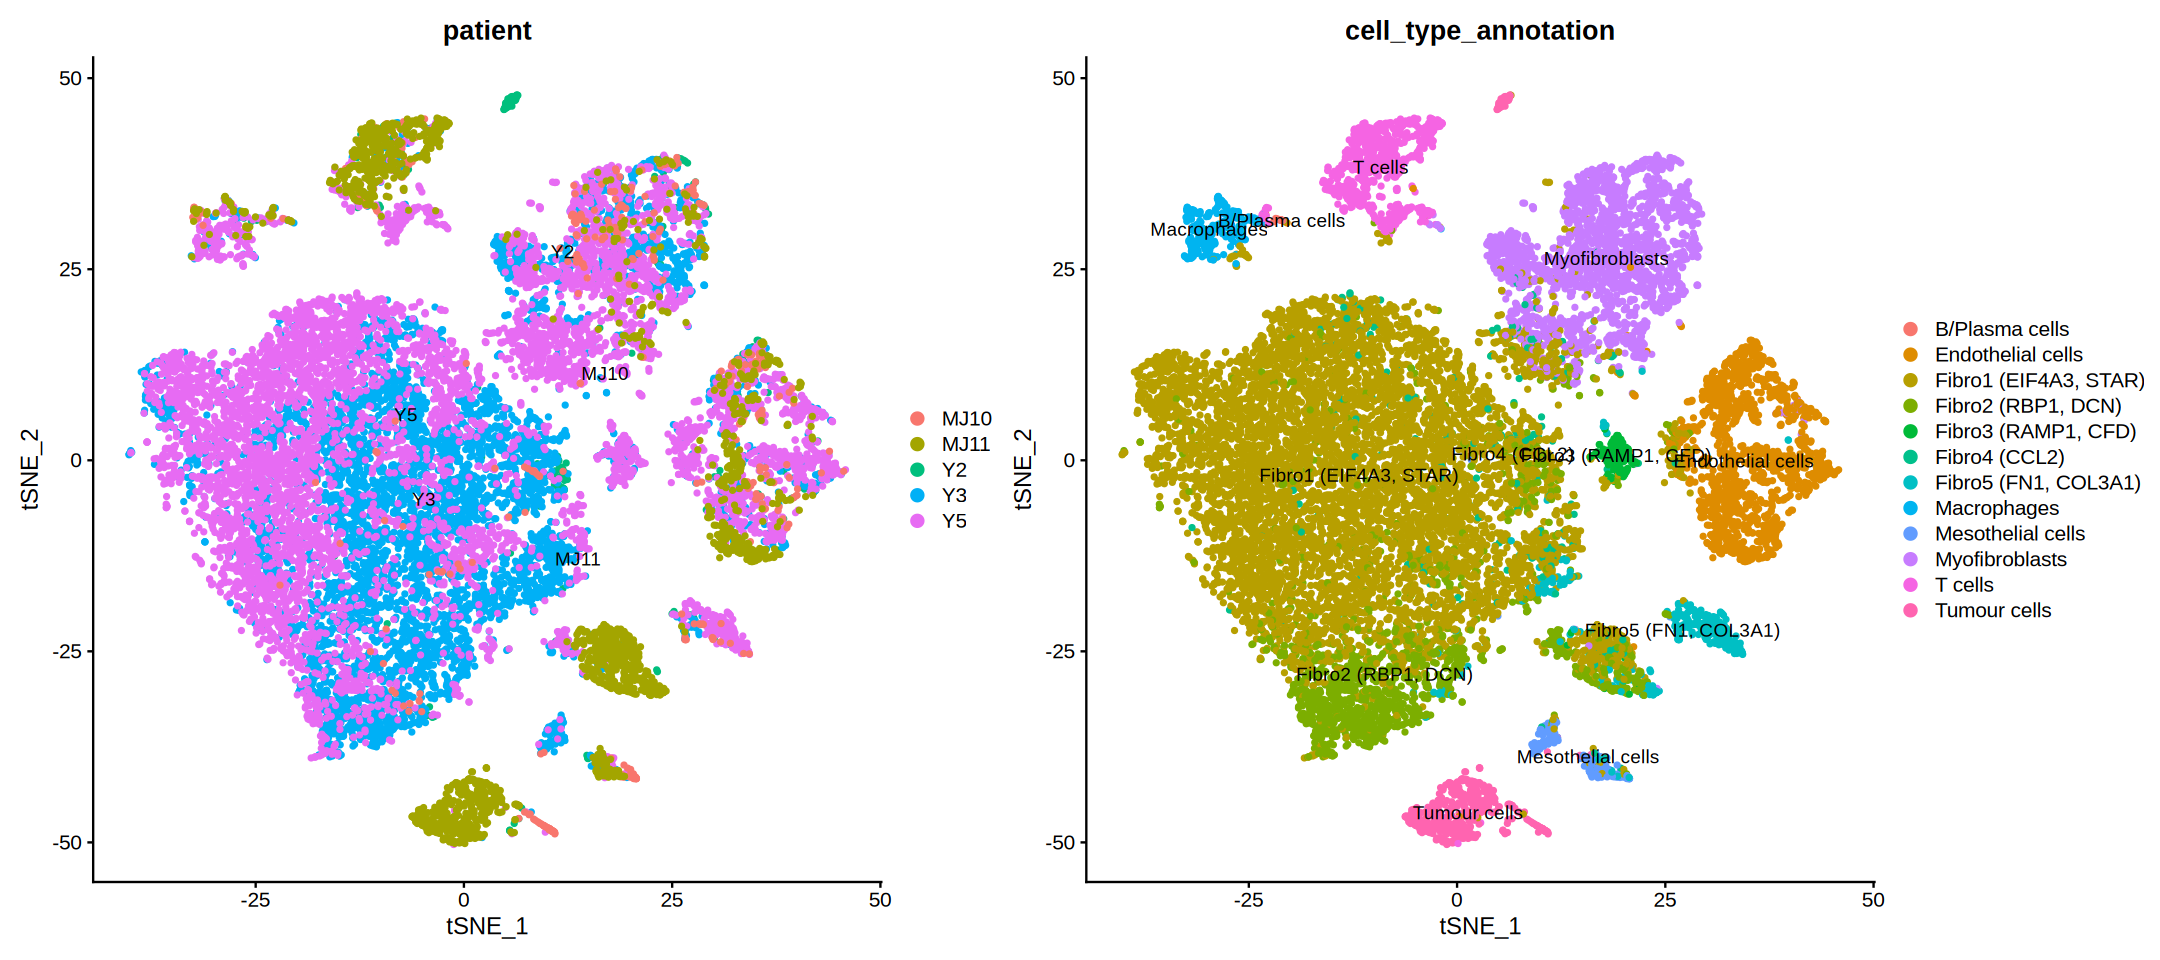

In [11]:
options(repr.plot.height = 8, repr.plot.width = 18)
p1 <- DimPlot(merged_Ob, reduction = "tsne", label = TRUE, group.by = "patient", pt.size = 1, )
p2 <- DimPlot(merged_Ob, reduction = "tsne", label = TRUE, group.by = "cell_type_annotation", pt.size = 1, )
p1 + p2

In [12]:
# Integrate the data from all samples using CCA method
intSCOb <- IntegrateLayers(object = merged_Ob, method = "CCAIntegration", orig.reduction = "pca", 
                           #normalization.method = "SCT",if normalisation technique is SCTransform
                           new.reduction = "integrated.cca",
                           verbose = FALSE)

# re-join layers after integration
intSCOb[["RNA"]] <- JoinLayers(intSCOb[["RNA"]])
print(intSCOb)

An object of class Seurat 
19915 features across 16682 samples within 1 assay 
Active assay: RNA (19915 features, 3000 variable features)
 3 layers present: data, counts, scale.data
 4 dimensional reductions calculated: pca, tsne, umap, integrated.cca


In [13]:
# save processed object
outDir <- file.path("./../data/")
saveRDS(intSCOb, file= file.path(outDir, 'integrated_scRNASeq_data.rds'))